In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import shutil
import os

base = '/content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working'

# Verify the path exists and show contents
print("Drive folder contents:", os.listdir(base))

# Copy files that exist
shutil.copy(f'{base}/models.py', '/content/models.py')
shutil.copy(f'{base}/best_model.pth', '/content/best_model.pth')

# Create era5_utils.py directly here instead of copying from Drive
era5_code = '''
import cdsapi
import xarray as xr
import numpy as np

def get_era5_wind(lat, lon, date):
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
            "year": date[:4],
            "month": date[5:7],
            "day": date[8:10],
            "time": "12:00",
            "data_format": "netcdf",
            "download_format": "unarchived",
            "area": [lat + 0.25, lon - 0.25, lat - 0.25, lon + 0.25],
        },
        "era5.nc"
    )
    ds = xr.open_dataset("era5.nc")
    u = float(ds["u10"].mean().values)
    v = float(ds["v10"].mean().values)
    return float((u**2 + v**2)**0.5)
'''

with open('/content/era5_utils.py', 'w') as f:
    f.write(era5_code)

print(os.listdir('/content'))

Drive folder contents: ['best_model.pth', 'S2B_MSIL2A_20210101T070309_N0500_R063_T40SBE_20230403T210805.SAFE.zip', 'models.py', 'Output File Created (After running the CH4_Pipeline_Clean.ipynb)', 'Output_2 (After running the CH4_Pipeline)', 'European_CH4_Pipeline.ipynb', 'Turkmenistan_CH4_Pipeline.ipynb', 'outputs']
['.config', 'drive', 'repo', 'results', '__pycache__', 'best_model.pth', 'detection_result.png', 'data', 'era5_utils.py', 'rgb_patch.png', 'era5.nc', 'models.py', 'sample_data']


In [3]:
import os

for root, dirs, files in os.walk('/content/drive'):
    for f in files:
        if 'S2B_MSIL2A' in f:
            full_path = os.path.join(root, f)
            print(full_path)

/content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working/S2B_MSIL2A_20210101T070309_N0500_R063_T40SBE_20230403T210805.SAFE.zip


In [4]:
import zipfile
import os

zip_path = '/content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working/S2B_MSIL2A_20210101T070309_N0500_R063_T40SBE_20230403T210805.SAFE.zip'
extract_path = '/content/data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('Unzipped!')

Unzipped!


In [5]:
import os, glob, rasterio, numpy as np
from rasterio.enums import Resampling

safe_folder = glob.glob('/content/data/*.SAFE')[0]
img_folder = os.path.join(safe_folder, 'GRANULE')
granule = os.listdir(img_folder)[0]
img_data = os.path.join(img_folder, granule, 'IMG_DATA')

all_jp2 = []
for res in ['R10m', 'R20m', 'R60m']:
    path = os.path.join(img_data, res)
    if os.path.exists(path):
        all_jp2 += glob.glob(os.path.join(path, '*.jp2'))

wanted = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']
selected = []
for w in wanted:
    match = [f for f in all_jp2 if f'_{w}_' in os.path.basename(f)]
    if match:
        selected.append(match[0])

ref_file = [f for f in selected if '_B02_' in os.path.basename(f)][0]

with rasterio.open(ref_file) as ref:
    target_height = ref.height
    target_width  = ref.width
    transform     = ref.transform
    src_crs       = ref.crs

print(f'Scene size: {target_height} x {target_width}')
print(f'CRS: {src_crs}')
print(f'Selected {len(selected)} bands')
print('Band loading ready - using tile-by-tile mode to save RAM')

Scene size: 10980 x 10980
CRS: EPSG:32640
Selected 12 bands
Band loading ready - using tile-by-tile mode to save RAM


In [6]:
import torch
from models import Unet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = Unet(in_channels=12, out_channels=1, div_factor=1).to(device)
ckpt  = torch.load('best_model.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print('Model loaded.')

patch_size = 100
stride     = 500
threshold  = 0.25

best_score    = -1
best_prob_max = -1
best_coords   = None
best_prob     = None
best_mask     = None
best_patch    = None

src_files = [rasterio.open(f) for f in selected]

try:
    for y in range(0, target_height - patch_size + 1, stride):
        for x in range(0, target_width - patch_size + 1, stride):

            arrays = []
            skip = False
            for src in src_files:
                # Scale the window to each band's native resolution
                x_scale = src.width  / target_width
                y_scale = src.height / target_height

                x_src = int(x * x_scale)
                y_src = int(y * y_scale)
                w_src = max(1, int(patch_size * x_scale))
                h_src = max(1, int(patch_size * y_scale))

                # Skip if window goes out of bounds for this band
                if x_src + w_src > src.width or y_src + h_src > src.height:
                    skip = True
                    break

                arr = src.read(
                    1,
                    window=rasterio.windows.Window(x_src, y_src, w_src, h_src),
                    out_shape=(patch_size, patch_size),
                    resampling=Resampling.bilinear
                )
                arrays.append(arr.astype(np.float32))

            if skip:
                continue

            patch    = np.stack(arrays, axis=-1) / 10000.0
            arr      = np.transpose(patch, (2, 0, 1))
            x_tensor = torch.from_numpy(arr).unsqueeze(0).to(device)

            with torch.no_grad():
                out = model(x_tensor)

            prob = out.squeeze().detach().cpu().numpy()
            mask = (prob > threshold).astype(np.uint8)

            score    = mask.sum()
            prob_max = prob.max()

            if score > best_score or (score == best_score and prob_max > best_prob_max):
                best_score    = score
                best_prob_max = prob_max
                best_coords   = (y, x)
                best_prob     = prob.copy()
                best_mask     = mask.copy()
                best_patch    = patch.copy()

finally:
    for src in src_files:
        src.close()

print('\n===== Scan Finished =====')
print('Best patch top-left:', best_coords)
print('Best plume pixels:',   best_score)
print('Best prob max:',       round(best_prob_max, 6))

Using device: cuda
Model loaded.

===== Scan Finished =====
Best patch top-left: (10500, 9500)
Best plume pixels: 779
Best prob max: 0.741096


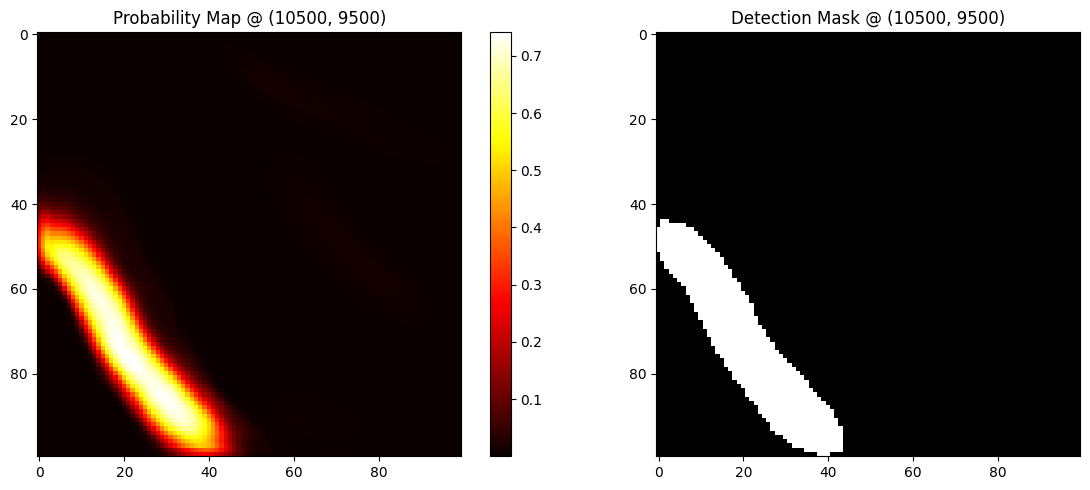

Detection visualization saved.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(best_prob, cmap='hot')
plt.colorbar(im, ax=axes[0])
axes[0].set_title(f'Probability Map @ {best_coords}')

axes[1].imshow(best_mask, cmap='gray')
axes[1].set_title(f'Detection Mask @ {best_coords}')

plt.tight_layout()
plt.savefig('/content/detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Detection visualization saved.')

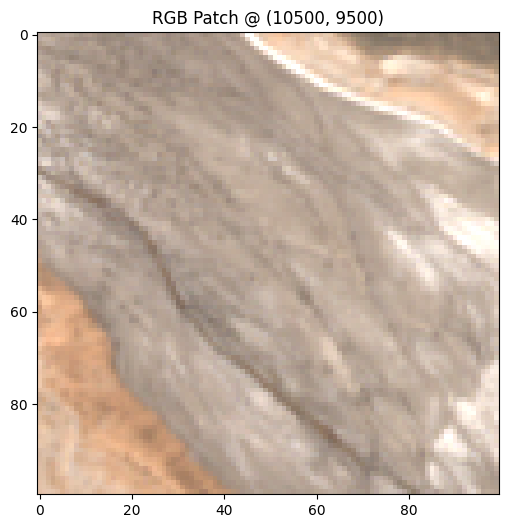

RGB patch saved.


In [8]:
rgb = best_patch[:, :, [3, 2, 1]]
rgb = np.clip(rgb / np.percentile(rgb, 99), 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f'RGB Patch @ {best_coords}')
plt.savefig('/content/rgb_patch.png', dpi=150, bbox_inches='tight')
plt.show()
print('RGB patch saved.')

In [9]:
from rasterio.transform import xy
from pyproj import Transformer

def pixel_to_latlon(y, x, transform, src_crs):
    px, py = xy(transform, y, x, offset='center')
    transformer = Transformer.from_crs(src_crs, 'EPSG:4326', always_xy=True)
    lon, lat = transformer.transform(px, py)
    return float(lat), float(lon)

y, x = best_coords
centroid_lat, centroid_lon = pixel_to_latlon(y + 50, x + 50, transform, src_crs)

print('Centroid lat:', centroid_lat)
print('Centroid lon:', centroid_lon)

Centroid lat: 35.17279348072927
Centroid lon: 54.7542437811491


In [10]:
!pip install -q cdsapi xarray netCDF4

from google.colab import userdata
cds_key = userdata.get('CDS_API_KEY')
with open('/root/.cdsapirc', 'w') as f:
    f.write(f'url: https://cds.climate.copernicus.eu/api\nkey: {cds_key}\n')

from era5_utils import get_era5_wind

wind = get_era5_wind(centroid_lat, centroid_lon, '2021-01-01')
print('ERA5 wind speed:', round(wind, 4), 'm/s')

2026-04-10 06:51:47,808 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

9e6faabb1cbeb663aa5711e603d7fa78.nc:   0%|          | 0.00/33.3k [00:00<?, ?B/s]

ERA5 wind speed: 1.5846 m/s


In [11]:
import shutil

base = '/content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working'
output_dir = f'{base}/outputs'
os.makedirs(output_dir, exist_ok=True)

shutil.copy('/content/detection_result.png', f'{output_dir}/detection_result.png')
shutil.copy('/content/rgb_patch.png',        f'{output_dir}/rgb_patch.png')

print('All outputs saved to Drive.')
print(f'Location: {output_dir}')

All outputs saved to Drive.
Location: /content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working/outputs


In [12]:
import importlib
import sys

# Remove duplicate entries and force clean path
sys.path = [p for p in sys.path if p != '/content/repo']
sys.path.insert(0, '/content/repo')

# Force reimport
import importlib.util
spec = importlib.util.spec_from_file_location(
    "run_cemf",
    "/content/repo/src/quantification/cemf.py"
)
cemf_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cemf_module)

run_cemf  = cemf_module.run_cemf
CEMFResult = cemf_module.CEMFResult

print('run_cemf loaded successfully')

# Now load ime.py the same way
spec2 = importlib.util.spec_from_file_location(
    "ime",
    "/content/repo/src/quantification/ime.py"
)
ime_module = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(ime_module)

CEMFIntegratedMassEnhancement = ime_module.CEMFIntegratedMassEnhancement
print('CEMFIntegratedMassEnhancement loaded successfully')

# Now run CEMF
b11_file = [f for f in selected if '_B11_' in os.path.basename(f)][0]
b12_file = [f for f in selected if '_B12_' in os.path.basename(f)][0]

y, x = best_coords

def read_patch(filepath, y, x, target_height, target_width, patch_size=100):
    with rasterio.open(filepath) as src:
        x_scale = src.width  / target_width
        y_scale = src.height / target_height
        x_src   = int(x * x_scale)
        y_src   = int(y * y_scale)
        w_src   = max(1, int(patch_size * x_scale))
        h_src   = max(1, int(patch_size * y_scale))
        arr = src.read(
            1,
            window=rasterio.windows.Window(x_src, y_src, w_src, h_src),
            out_shape=(patch_size, patch_size),
            resampling=Resampling.bilinear
        )
    return arr.astype(np.float32) / 10000.0

b11_patch = read_patch(b11_file, y, x, target_height, target_width)
b12_patch = read_patch(b12_file, y, x, target_height, target_width)

cemf_result = run_cemf(
    b11=b11_patch,
    b12=b12_patch,
    mask=best_mask,
    scene_id="S2B_MSIL2A_20210101T070309_N0500_R063_T40SBE_20230403T210805",
    timestamp="2021-01-01T07:03:09Z"
)

print(f'CEMF valid:     {cemf_result.retrieval_valid}')
print(f'Plume pixels:   {cemf_result.n_plume_pixels}')
print(f'Total mass:     {cemf_result.total_mass_kg:.6f} kg')
if cemf_result.warning:
    print(f'Warning:        {cemf_result.warning}')

run_cemf loaded successfully
CEMFIntegratedMassEnhancement loaded successfully
CEMF valid:     True
Plume pixels:   779
Total mass:     43.398167 kg


In [13]:
# ===== IME — Physical Emission Rate using repo module =====

ime_engine = CEMFIntegratedMassEnhancement()

q_result = ime_engine.estimate_from_cemf(
    cemf_result=cemf_result,
    wind_speed_ms=float(wind),
    wind_source='ERA5_reanalysis'
)

# Extract values for logging
Q_kg_per_h           = q_result.flow_rate_kgh
Q_lower              = q_result.flow_rate_lower_kgh
Q_upper              = q_result.flow_rate_upper_kgh
plume_length_m       = q_result.plume_length_m
total_mass_kg        = cemf_result.total_mass_kg
annual_tonnes        = q_result.annual_tonnes
ira_waste_charge_usd = q_result.ira_waste_charge_usd

print('===== Physical Emission Rate =====')
print(f'Plume length:          {plume_length_m:.1f} m')
print(f'Total mass:            {total_mass_kg:.6f} kg')
print(f'Wind speed (ERA5):     {wind:.4f} m/s')
print(f'Q (flow rate):         {Q_kg_per_h:.2f} kg/h')
print(f'Q lower bound (-40%):  {Q_lower:.2f} kg/h')
print(f'Q upper bound (+40%):  {Q_upper:.2f} kg/h')
print(f'Annual tonnes:         {annual_tonnes:.1f} t/yr')
print(f'IRA liability (2026):  ${ira_waste_charge_usd:,.0f}')
print(f'Wind source:           ERA5_reanalysis')
print(f'Methodology:           CEMF+IME (Varon et al. 2021)')

===== Physical Emission Rate =====
Plume length:          1100.0 m
Total mass:            43.398167 kg
Wind speed (ERA5):     1.5846 m/s
Q (flow rate):         225.05 kg/h
Q lower bound (-40%):  135.03 kg/h
Q upper bound (+40%):  315.07 kg/h
Annual tonnes:         1971.4 t/yr
IRA liability (2026):  $2,957,157
Wind source:           ERA5_reanalysis
Methodology:           CEMF+IME (Varon et al. 2021)


In [14]:
# ===== Log result to JSONL =====
import json
import os
from datetime import datetime

record = {
    "logged_at":                    datetime.utcnow().isoformat() + "Z",
    "scene_id":                     "S2B_MSIL2A_20210101T070309_N0500_R063_T40SBE_20230403T210805",
    "acquisition_timestamp":        "2021-01-01T07:03:09Z",
    "plume_centroid_lat":           centroid_lat,
    "plume_centroid_lon":           centroid_lon,
    "q_cemf_kg_per_hour":           round(float(Q_kg_per_h), 4),
    "q_lower_kg_per_hour":          round(float(Q_lower), 4),
    "q_upper_kg_per_hour":          round(float(Q_upper), 4),
    "uncertainty_pct":              40,
    "ch4net_peak_probability":      round(float(best_prob_max), 6),
    "cloud_cover_quality":          "Optimal",
    "wind_speed_ms":                round(float(wind), 4),
    "wind_source":                  "ERA5_reanalysis",
    "n_plume_pixels":               int(best_mask.sum()),
    "pixel_area_m2":                400,
    "plume_length_m":               round(float(plume_length_m), 1),
    "total_mass_kg":                round(float(total_mass_kg), 6),
    "annual_tonnes_if_continuous":  round(float(annual_tonnes), 2),
    "ira_waste_charge_usd_2026":    round(float(ira_waste_charge_usd), 2),
    "methodology":                  "CEMF+IME",
    "sensor":                       "Sentinel-2 L2A",
    "retrieval_notes":              f"Wind: ERA5 reanalysis {round(float(wind), 4)} m/s. "
                                    f"Plume length: {round(float(plume_length_m), 1)} m. "
                                    f"Uncertainty +/-40% per Varon et al. (2021)."
}

os.makedirs('/content/results', exist_ok=True)
jsonl_path = '/content/results/emission_timeseries.jsonl'

with open(jsonl_path, 'w') as f:
    f.write(json.dumps(record) + '\n')

print('Record written to:', jsonl_path)
print()
print(json.dumps(record, indent=2))

Record written to: /content/results/emission_timeseries.jsonl

{
  "logged_at": "2026-04-10T06:52:12.650015Z",
  "scene_id": "S2B_MSIL2A_20210101T070309_N0500_R063_T40SBE_20230403T210805",
  "acquisition_timestamp": "2021-01-01T07:03:09Z",
  "plume_centroid_lat": 35.17279348072927,
  "plume_centroid_lon": 54.7542437811491,
  "q_cemf_kg_per_hour": 225.05,
  "q_lower_kg_per_hour": 135.03,
  "q_upper_kg_per_hour": 315.07,
  "uncertainty_pct": 40,
  "ch4net_peak_probability": 0.741096,
  "cloud_cover_quality": "Optimal",
  "wind_speed_ms": 1.5846,
  "wind_source": "ERA5_reanalysis",
  "n_plume_pixels": 779,
  "pixel_area_m2": 400,
  "plume_length_m": 1100.0,
  "total_mass_kg": 43.398167,
  "annual_tonnes_if_continuous": 1971.44,
  "ira_waste_charge_usd_2026": 2957157.0,
  "methodology": "CEMF+IME",
  "sensor": "Sentinel-2 L2A",
  "retrieval_notes": "Wind: ERA5 reanalysis 1.5846 m/s. Plume length: 1100.0 m. Uncertainty +/-40% per Varon et al. (2021)."
}


/tmp/ipykernel_5566/4002673545.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "logged_at":                    datetime.utcnow().isoformat() + "Z",


In [15]:
# ===== Save all outputs to Drive =====
output_dir = f'{base}/outputs'
os.makedirs(output_dir, exist_ok=True)

shutil.copy('/content/detection_result.png',
            f'{output_dir}/detection_result.png')
shutil.copy('/content/rgb_patch.png',
            f'{output_dir}/rgb_patch.png')
shutil.copy('/content/results/emission_timeseries.jsonl',
            f'{output_dir}/emission_timeseries.jsonl')

print('All outputs saved to Drive:')
print(f'  {output_dir}/detection_result.png')
print(f'  {output_dir}/rgb_patch.png')
print(f'  {output_dir}/emission_timeseries.jsonl')

All outputs saved to Drive:
  /content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working/outputs/detection_result.png
  /content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working/outputs/rgb_patch.png
  /content/drive/.shortcut-targets-by-id/19xUy-jzTPqj83OSmQQAXyxJ2gmVw5tG6/EIB_2/Code & Data/CH4_Pipeline_Working/outputs/emission_timeseries.jsonl
